In [1]:
import numpy as np
import pandas as pd
from datetime import date
import collections
import datetime
import os
import xarray as xr
import csv
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
import itertools


## Generic the filepath to the main data folder
fpath0 = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/'

scenarios = ['ssp126','ssp245','ssp370','ssp585']

modelnames = ['BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 
                  'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']

gmodels = ['GloGEM', 'PyGEM', 'OGGM']

parameter_names = {}
for SSP in scenarios:
    parameter_names[SSP] = ['Aridity_Index_Avg', 'Average Precipitation Trend', 'GlacierAreaFrac', f"Mean_Volume_Loss_{SSP}", f"Mean_Initial_Volumes_{SSP}", '#glaciers']

In [2]:
# Create an empty dictionary to store DataFrames of parameters for each gmodel
parameters = {}
    
for g, gmodel in enumerate(gmodels):
    file = f"MASTER_{gmodel}.csv"
    temp_df = pd.read_csv(fpath0 + 'Parameters/MASTERS/'+ file, index_col=0)

    # Store the combined_df in the dictionary for each SSP
    parameters[gmodel] = temp_df

In [3]:
#Creating single SSP dfs
PARAMETERS = {}
for SSP in scenarios:
    PARAMETERS[SSP] = {}
    for gmodel in gmodels:
        # Create a copy of the original DataFrame
        temp_df = parameters[gmodel].copy()
    
        # Exclude the specific columns for each DataFrame
        #temp_df =  [col for col in parameters[gmodel].columns if 'Mean_Volume_Loss' not in col or ssp in col and 'Mean_Initial_Volumes' not in col or ssp in col]
        #temp_df2 = [col for col in parameters[gmodel].columns if f"Mean_Initial_Volumes_{ssp}" not in col]
        temp_df_columns = [col for col in parameters[gmodel].columns if ('Mean_Volume_Loss' not in col or SSP in col) and ('Mean_Initial_Volumes' not in col or SSP in col)]

        PARAMETERS[SSP][gmodel] = temp_df[temp_df_columns]

In [6]:
PARAMETERS

{'ssp126': {'GloGEM':              Aridity_Index_Avg  Average Precipitation Trend  GlacierAreaFrac  \
  RHINE                 1.927593                 4.252499e+08         0.002063   
  RHONE                 1.196167                 1.288114e+09         0.009475   
  PO                    2.470102                 1.257263e+09         0.004275   
  DANUBE                1.169773                 8.300483e+08         0.000510   
  TITICACA              0.720193                 2.470217e+08         0.003817   
  ...                        ...                          ...              ...   
  GANGES                1.209703                -3.051695e+07         0.007851   
  BRAHMAPUTRA           1.905143                -7.708618e+07         0.019472   
  OB                    1.694124                -7.635888e+07         0.000251   
  INDIGIRKA             9.077289                -4.872449e+06         0.000502   
  YANGTZE               3.362468                 3.188919e+07         0.000943

In [4]:
mean_initial_volumes = {}

for SSP in scenarios:
    mean_initial_volumes[SSP] = pd.DataFrame()
    for gmodel in gmodels:
        # Extract the relevant column for Mean_Initial_Volumes_ssp585
        column_name = f"Mean_Initial_Volumes_{SSP}"
        mean_initial_volumes[SSP][gmodel] = PARAMETERS[SSP][gmodel][column_name]

In [5]:
init_vol_and_mean = {}
relative_init_volume = {}
for SSP in scenarios:
        new_df = mean_initial_volumes[SSP].copy()
        mean_df = new_df.mean(axis=1)
        mean_df = pd.DataFrame({'Mean': mean_df})

        #Creating a new concatenated df
        init_vol_and_mean[SSP] = pd.concat([mean_initial_volumes[SSP], mean_df], axis = 1) 
        #And relative df    
        relative_init_volume[SSP] = mean_initial_volumes[SSP].divide(mean_df['Mean'], axis=0)

In [7]:
relative_init_volume[SSP]

,GloGEM,PyGEM,OGGM
RHINE,1.026256,0.957580,1.016164
RHONE,1.033764,0.962468,1.003768
PO,0.965302,0.990879,1.043819
DANUBE,0.978447,0.984435,1.037118
TITICACA,0.990322,1.037940,0.971738
...,...,...,...
GANGES,0.994254,0.933537,1.072209
BRAHMAPUTRA,0.994980,0.999077,1.005942
OB,0.987959,0.949446,1.062594
INDIGIRKA,0.953178,0.974304,1.072518


In [8]:
GlacAreaFrac = pd.DataFrame(index=PARAMETERS[SSP][gmodels[0]].index)

for gmodel in gmodels:
    column_name = 'GlacierAreaFrac'
    GlacAreaFrac[gmodel] = PARAMETERS[SSP][gmodel][column_name]


In [9]:
GlacAreaFrac_and_mean = {}
relative_GlacAreaFrac = {}

new_df = GlacAreaFrac.copy()
mean_df = new_df.mean(axis=1)
mean_df = pd.DataFrame({'Mean': mean_df})

#Creating a new concatenated df
GlacAreaFrac_and_mean = pd.concat([GlacAreaFrac, mean_df], axis = 1) 
#And relative df    
relative_GlacAreaFrac = GlacAreaFrac.divide(mean_df['Mean'], axis=0)

In [10]:
relative_GlacAreaFrac.index

Index(['RHINE', 'RHONE', 'PO', 'DANUBE', 'TITICACA', 'SANTA', 'OCONA', 'MAJES',
       'MAGDALENA', 'AMAZON', 'YELCHO', 'VALDIVIA', 'SERRANO', 'RAPEL',
       'PUELO', 'PASCUA', 'PALENA', 'HUASCO', 'COPIAPO', 'CISNES', 'BIOBIO',
       'BAKER', 'AZOPARDO', 'AISEN', 'SANTA CRUZ', 'NEGRO', 'COLORADO',
       'CHICO', 'TORNEALVEN', 'THJORSA', 'OLFUSA', 'LULEALVEN', 'KUBAN',
       'KALIXALVEN', 'GLOMAA', 'DRAMSELVA', 'SVARTA', 'LAGARFLJOT',
       'JOKULSA A FJOLLUM', 'CLUTHA', 'YUKON', 'TAKU', 'SUSITNA', 'STIKINE',
       'SKEENA', 'SKAGIT', 'NUSHAGAK', 'NASS', 'KUSKOKWIM', 'FRASER', 'COPPER',
       'COLUMBIA', 'ALSEK', 'NELSON', 'MACKENZIE', 'COLVILLE', 'YSYK-KOL',
       'UVS NUUR', 'TARIM HE', 'TALAS', 'LAKE BALKHASH', 'HAR US NUUR', 'CHUY',
       'ARAL SEA', 'YELLOW RIVER', 'MEKONG', 'KAMCHATKA', 'SALWEEN',
       'IRRAWADDY', 'INDUS', 'GANGES', 'BRAHMAPUTRA', 'OB', 'INDIGIRKA',
       'YANGTZE'],
      dtype='object')

In [11]:
for basin in relative_GlacAreaFrac.index:
    if relative_init_volume['ssp245']['GloGEM'].loc[basin]>1.2:
        print(basin + str(relative_init_volume['ssp245']['GloGEM'].loc[basin]))

VALDIVIA1.2492149218334383


In [12]:
# Create an empty dictionary to store RMQ DataFrames for each GCM and SSP
RMQ = {}
    
for s, SSP in enumerate(scenarios):
    RMQ[SSP] = {}
    for m, GCM in enumerate(modelnames):
        
        file = f"RMQ{GCM}_{SSP}.csv"
        temp_df = pd.read_csv(fpath0 + 'RMQ/'+ file, index_col=0)
    
        # Store the combined_df in the dictionary for each SSP
        RMQ[SSP][GCM] = temp_df

In [13]:
#Create new dict to store multi-GCM means
RMQ_GCM_means = {}
for g, gmodel in enumerate(gmodels):
    RMQ_GCM_means[gmodel] = {}
    for s, SSP in enumerate(scenarios):
        all_GCMs = []
        for m, GCM in enumerate(modelnames):
            all_GCMs.append(RMQ[SSP][GCM][gmodel])
            
        # Calculate the mean for each year across the models
        temp_df = pd.DataFrame(all_GCMs)
        RMQ_GCM_means[gmodel][SSP] = temp_df.mean(axis = 0)

Create parameter vs RMQ plots to visualize basic correlations:

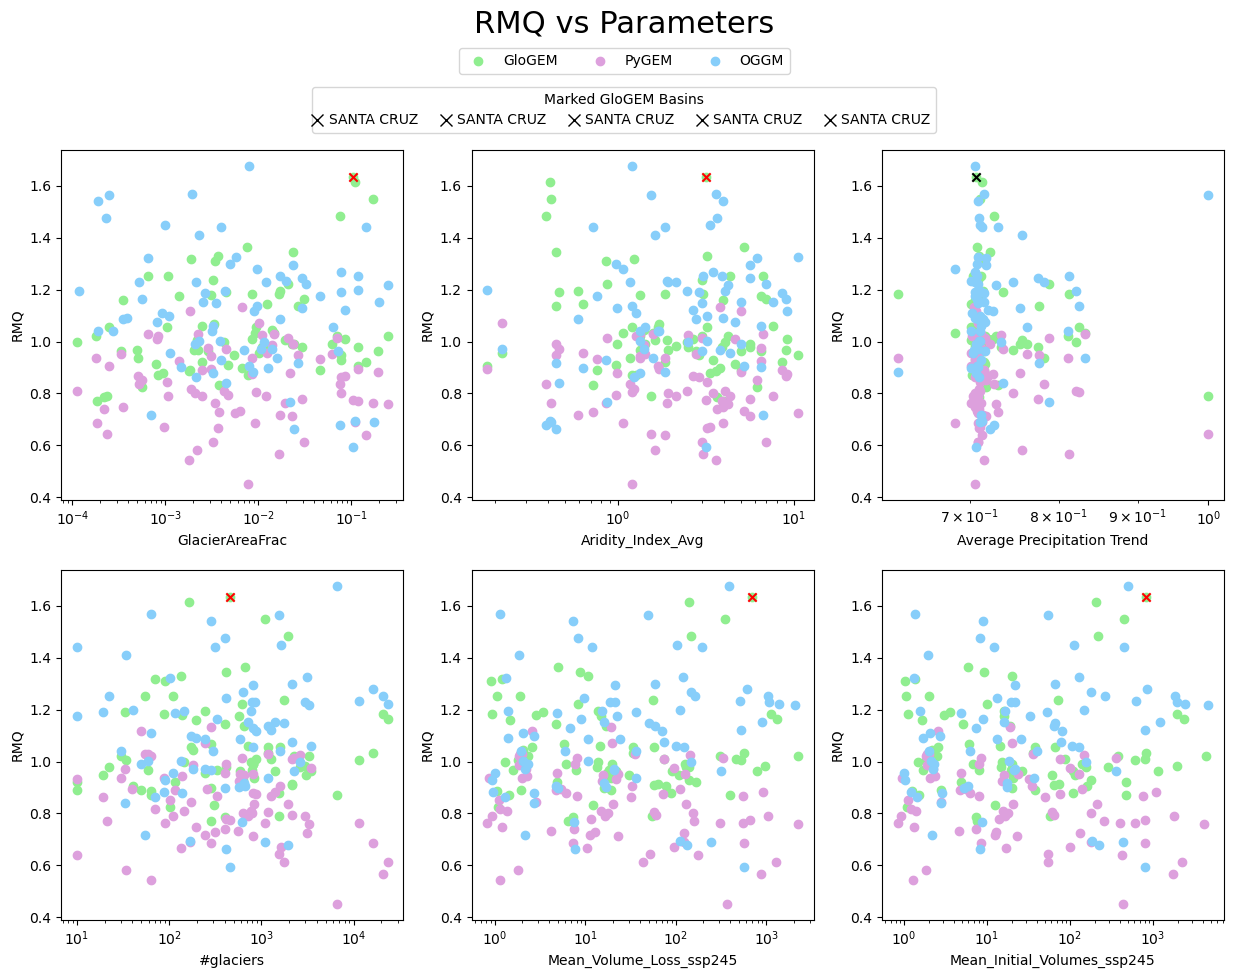

In [14]:
import matplotlib.lines as mlines
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# List of colors for each gmodel
colors = {'GloGEM': 'lightgreen', 'PyGEM': 'plum', 'OGGM': 'lightskyblue'}
# List of basins to highlight
basins_of_interest = ['SANTA CRUZ', 'CLUTHA', 'SERRANO', 'BAKER', 'PASCUA', 'KAMCHATKA', 'KUBAN']  # Replace with your actual basin indices or names
# Define markers or colors for each basin
basin_markers = {'SANTA CRUZ': 'x', 'CLUTHA': 'o', 'SERRANO': '^', 'BAKER': '+', 'PASCUA': 's', 'KAMCHATKA': 'v', 'KUBAN' :'.'}
basins_of_interest = ['SANTA CRUZ']
basin_markers = {'SANTA CRUZ': 'x'}
# Focusing on a single SSP
SSP = 'ssp245'
parameternames = parameter_names[SSP]

# subplot indexing
num_cols = 3
c = 0
r = -1

handles_gmodel = []  # For gmodel legend

# Create handles_basins outside of the loop
handles_basins = []

for p, parameter in enumerate(parameternames):
    if c % 3 == 0:
        r += 1
    c = (c + 1) % num_cols

    for g, gmodel in enumerate(gmodels):
        # Normalizing precip trend to imprive visualization:
        if parameter == 'Average Precipitation Trend':
            scaler = MinMaxScaler()
            data_to_normalize = PARAMETERS['ssp245'][gmodel].transpose().iloc[p]
            normalized_data = scaler.fit_transform(data_to_normalize.values.reshape(-1, 1)).flatten()
            # Create a DataFrame with basin names and normalized values
            normalized_df = pd.DataFrame({'Normalized': normalized_data}, index=data_to_normalize.index)

            # Scatter plot with color
            sc = axes[r, c].scatter(normalized_data, RMQ_GCM_means[gmodel]['ssp245'], label=gmodel, color=colors[gmodel])

        else:
            sc = axes[r, c].scatter(PARAMETERS[SSP][gmodel].transpose().iloc[p], RMQ_GCM_means[gmodel][SSP], label=gmodel, color=colors[gmodel])
        if len(handles_gmodel) < 3:
            handles_gmodel.append(sc)

        # Highlight basins of interest with different markers or colors
        for basin in basins_of_interest:
            if gmodel == 'GloGEM' and basin in basin_markers and parameter != 'Average Precipitation Trend':
                x = PARAMETERS[SSP][gmodel].transpose().iloc[p][basin]
                y = RMQ_GCM_means[gmodel][SSP][basin]
                marker = basin_markers[basin]
                sc = axes[r, c].scatter(x, y, color='red', marker=marker, label=basin)
            if len(handles_basins) < 5:
                handles_basins.append(mlines.Line2D([], [], color='black', marker=marker, markersize=8, label=basin))

                
            if gmodel == 'GloGEM' and basin in basin_markers and parameter == 'Average Precipitation Trend':
                x = normalized_df.loc[basin, 'Normalized']
                y = RMQ_GCM_means[gmodel][SSP][basin]
                marker = basin_markers[basin]
                sc = axes[r, c].scatter(x, y, color='black', marker=marker, label=basin)
        
        #if not (r == 0 and c == 2):
        axes[r, c].semilogx()  # Use regular plot without log scale
            # axes[r, c].set_xscale('symlog')  # Adjust linthreshx as needed

        axes[r, c].set_xlabel(parameter)
        axes[r, c].set_ylabel('RMQ')

# Adjust layout
fig.suptitle('RMQ vs Parameters', fontsize=22, y=1.02)

# Create separate legend for gmodels
axes[0, 0].legend(handles=handles_gmodel, bbox_to_anchor=(2.15, 1.31), ncol=3)

# Create a single legend for basins outside of the loop
fig.legend(handles=handles_basins, bbox_to_anchor=(0.5, 0.89), loc="lower center", ncol=5, title='Marked GloGEM Basins',handlelength=0)

plt.show()

Plotting RMQ vs relative initial volume with a linear regression:

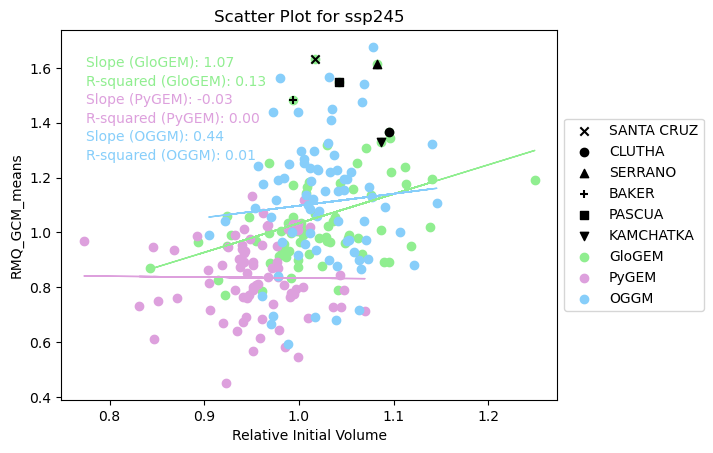

In [15]:
# Specify the SSP you want to plot
SSP = 'ssp245'  # Replace 'your_selected_SSP' with the SSP you want to plot
colors = {'GloGEM': 'lightgreen', 'PyGEM': 'plum', 'OGGM': 'lightskyblue'}
# List of basins to highlight
basins_of_interest = ['SANTA CRUZ', 'CLUTHA', 'SERRANO', 'BAKER', 'PASCUA', 'KAMCHATKA']  # Replace with your actual basin indices or names
# Define markers or colors for each basin
basin_markers = {'SANTA CRUZ': 'x', 'CLUTHA': 'o', 'SERRANO': '^', 'BAKER': '+', 'PASCUA': 's', 'KAMCHATKA': 'v'}

# Create a scatter plot for each gmodel
for i, gmodel in enumerate(gmodels):
    # Extract the data for the current gmodel
    rmq_values = RMQ_GCM_means[gmodel][SSP]
    column = f"{gmodel}_{SSP}"
    relative_volume_values = relative_init_volume[SSP][gmodel]
    
    # Linear regression
    coefficients = np.polyfit(relative_volume_values, rmq_values, 1)
    trendline = np.poly1d(coefficients)

    # Calculate R-squared
    correlation_matrix = np.corrcoef(relative_volume_values, rmq_values)
    correlation = correlation_matrix[0, 1]
    r_squared = correlation**2

    # Plot the linear regression line
    plt.plot(relative_volume_values, trendline(relative_volume_values), color=colors[gmodel], linestyle='-', linewidth=1)

    # Add annotations for slope and R-squared with dynamic vertical position
    plt.text(0.05, 0.9 - i * 0.1, f"Slope ({gmodel}): {coefficients[0]:.2f}", transform=plt.gca().transAxes, color=colors[gmodel])
    plt.text(0.05, 0.85 - i * 0.1, f"R-squared ({gmodel}): {r_squared:.2f}", transform=plt.gca().transAxes, color=colors[gmodel])

    for basin in basins_of_interest:
        if gmodel == 'GloGEM' and basin in basin_markers:
            x = relative_init_volume[SSP][gmodel].loc[basin]
            y = RMQ_GCM_means[gmodel][SSP][basin]
            marker = basin_markers[basin]
            plt.scatter(x, y, color='black', marker=marker, label=basin, zorder=2)

    # Plot the scatter plot
    plt.scatter(relative_volume_values, rmq_values, label=gmodel, color=colors[gmodel])

# Add labels and legend to the right
plt.xlabel('Relative Initial Volume')
plt.ylabel('RMQ_GCM_means')
plt.title(f'Scatter Plot for {SSP}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [111]:
relative_GlacAreaFrac

,GloGEM,PyGEM,OGGM
RHINE,0.984789,0.985762,1.029449
RHONE,0.993683,0.995480,1.010837
PO,0.988797,0.989162,1.022040
DANUBE,0.983696,0.998109,1.018195
TITICACA,0.983016,0.983562,1.033423
...,...,...,...
GANGES,0.997753,0.998165,1.004083
BRAHMAPUTRA,0.993080,0.992916,1.014004
OB,0.970270,0.971017,1.058713
INDIGIRKA,0.964243,0.967183,1.068574


In [116]:
area_n_aridity = {}
for gmodel in gmodels:
    area_n_aridity[gmodel] = relative_GlacAreaFrac[gmodel] * parameters[gmodel]['Aridity_Index_Avg']

In [118]:
area_n_aridity['OGGM']

RHINE          1.984359
RHONE          1.209130
PO             2.524544
DANUBE         1.191057
TITICACA       0.744264
                 ...   
GANGES         1.214642
BRAHMAPUTRA    1.931823
OB             1.793590
INDIGIRKA      9.699758
YANGTZE        3.445034
Length: 75, dtype: float64

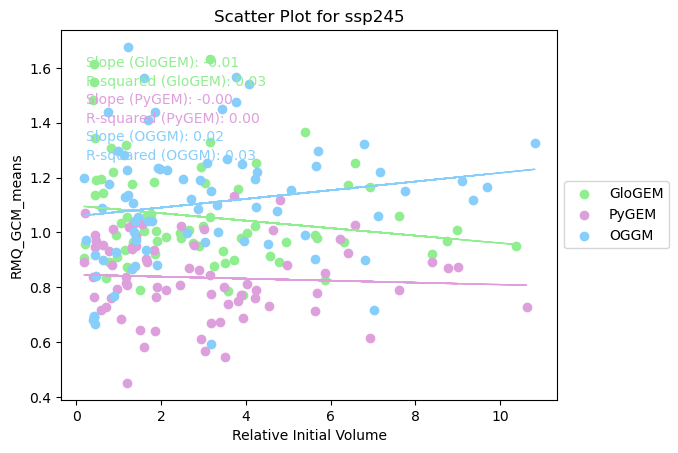

In [113]:
# Specify the SSP you want to plot
SSP = 'ssp245'  # Replace 'your_selected_SSP' with the SSP you want to plot
colors = {'GloGEM': 'lightgreen', 'PyGEM': 'plum', 'OGGM': 'lightskyblue'}
# List of basins to highlight
basins_of_interest = ['SANTA CRUZ', 'CLUTHA', 'SERRANO', 'BAKER', 'PASCUA', 'KAMCHATKA']  # Replace with your actual basin indices or names
# Define markers or colors for each basin
basin_markers = {'SANTA CRUZ': 'x', 'CLUTHA': 'o', 'SERRANO': '^', 'BAKER': '+', 'PASCUA': 's', 'KAMCHATKA': 'v'}

# Create a scatter plot for each gmodel
for i, gmodel in enumerate(gmodels):
    # Extract the data for the current gmodel
    rmq_values = RMQ_GCM_means[gmodel][SSP]
    column = f"{gmodel}_{SSP}"
    area_n_aridity = relative_GlacAreaFrac[gmodel] * parameters[gmodel]['Aridity_Index_Avg']
    
    # Linear regression
    coefficients = np.polyfit(area_n_aridity, rmq_values, 1)
    trendline = np.poly1d(coefficients)

    # Calculate R-squared
    correlation_matrix = np.corrcoef(area_n_aridity, rmq_values)
    correlation = correlation_matrix[0, 1]
    r_squared = correlation**2

    # Plot the linear regression line
    plt.plot(area_n_aridity, trendline(area_n_aridity), color=colors[gmodel], linestyle='-', linewidth=1)

    # Add annotations for slope and R-squared with dynamic vertical position
    plt.text(0.05, 0.9 - i * 0.1, f"Slope ({gmodel}): {coefficients[0]:.2f}", transform=plt.gca().transAxes, color=colors[gmodel])
    plt.text(0.05, 0.85 - i * 0.1, f"R-squared ({gmodel}): {r_squared:.2f}", transform=plt.gca().transAxes, color=colors[gmodel])

    # for basin in basins_of_interest:
    #     if gmodel == 'GloGEM' and basin in basin_markers:
    #         x = relative_init_volume[SSP][gmodel].loc[basin]
    #         y = RMQ_GCM_means[gmodel][SSP][basin]
    #         marker = basin_markers[basin]
    #         plt.scatter(x, y, color='black', marker=marker, label=basin, zorder=2)

    # Plot the scatter plot
    plt.scatter(area_n_aridity, rmq_values, label=gmodel, color=colors[gmodel])

# Add labels and legend to the right
plt.xlabel('Relative Initial Volume')
plt.ylabel('RMQ_GCM_means')
plt.title(f'Scatter Plot for {SSP}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [27]:
basins = {'RHINE':'6242', 'RHONE':'6243','PO':'6241', 'DANUBE':'6202', 'TITICACA':'3912', 'SANTA':'3425', 
            'OCONA':'3418', 'MAJES':'3416', 'MAGDALENA':'3227', 'AMAZON':'3203', 'YELCHO':'3429', 
            'VALDIVIA':'3428', 'SERRANO':'3426', 'RAPEL':'3423', 'PUELO':'3422', 'PASCUA':'3420', 
            'PALENA':'3419', 'HUASCO':'3412', 'COPIAPO':'3409', 'CISNES':'3408', 'BIOBIO':'3405', 'BAKER':'3404',
            'AZOPARDO':'3403', 'AISEN':'3401', 'SANTA CRUZ':'3244', 'NEGRO':'3232', 'COLORADO':'3212', 
            'CHICO':'3209', 'TORNEALVEN':'6255', 'THJORSA':'6254', 'OLFUSA':'6237', 'LULEALVEN':'6227', 
            'KUBAN':'6223', 'KALIXALVEN':'6219', 'GLOMAA':'6213', 'DRAMSELVA':'6209', 'SVARTA':'6110', 
            'LAGARFLJOT':'6104', 'JOKULSA A FJOLLUM':'6101', 'CLUTHA':'5406', 'YUKON':'4435', 'TAKU':'4431', 
             'SUSITNA':'4430','STIKINE':'4428', 'SKEENA':'4427','SKAGIT':'4426','NUSHAGAK':'4418','NASS':'4416',
            'KUSKOKWIM':'4414','FRASER':'4410', 'COPPER':'4408', 'COLUMBIA':'4406', 'ALSEK':'4401', 'NELSON':'4125', 
              'MACKENZIE':'4123','COLVILLE':'4110', 'YSYK-KOL':'2919', 'UVS NUUR':'2918', 'TARIM HE':'2914', 
              'TALAS':'2913', 'LAKE BALKHASH':'2910','HAR US NUUR':'2909', 'CHUY':'2905', 'ARAL SEA':'2902', 
              'YELLOW RIVER':'2434', 'MEKONG':'2421', 'KAMCHATKA':'2413', 'SALWEEN':'2319', 'IRRAWADDY':'2310', 
              'INDUS':'2309', 'GANGES':'2306','BRAHMAPUTRA':'2302', 'OB':'2108', 'INDIGIRKA':'2103','YANGTZE' : '2433'}

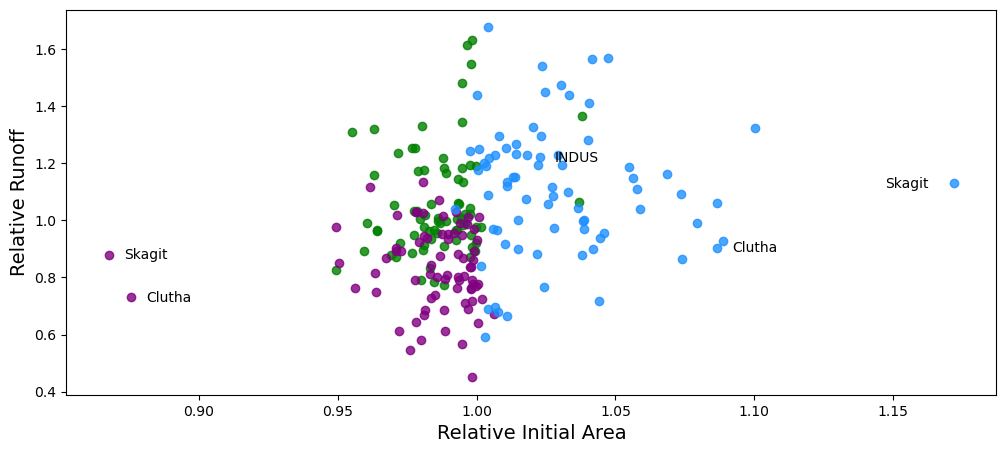

In [108]:
SSP = 'ssp245'  # Replace 'your_selected_SSP' with the SSP you want to plot
colors = {'GloGEM': 'green', 'PyGEM': 'purple', 'OGGM': 'dodgerblue'}
# List of basins to highlight
#basins_of_interest = ['AZOPARDO']  # Replace with your actual basin indices or names
basins_of_interest = basins
# Define markers or colors for each basin
#basin_markers = {'AZOPARDO': 'x'}

# Create a scatter plot for each gmodel
plt.figure(figsize=(12, 5))
for gmodel in gmodels:
    # Extract the data for the current gmodel
    rmq_values = RMQ_GCM_means[gmodel][SSP]
    #column = gmodel
    relative_area_values = relative_GlacAreaFrac[gmodel]
    if gmodel == 'GloGEM':
        #for basin in basins:
        x = relative_area_values
        y = rmq_values
    
            # Linear regression
        coefficients = np.polyfit(x, y, 1)
        trendline = np.poly1d(coefficients)

    # Plot the scatter plot
    plt.scatter(relative_area_values, rmq_values, label=gmodel, color=colors[gmodel], alpha = 0.8 )
    
x = relative_GlacAreaFrac['OGGM'].loc['SKAGIT']
y = RMQ_GCM_means['OGGM'][SSP]['SKAGIT']
plt.text(x-0.025, y-0.015, 'Skagit')

x = relative_GlacAreaFrac['OGGM'].loc['CLUTHA']
y = RMQ_GCM_means['OGGM'][SSP]['CLUTHA']
plt.text(x+0.0055, y-0.015, 'Clutha')

x = relative_GlacAreaFrac['PyGEM'].loc['SKAGIT']
y = RMQ_GCM_means['PyGEM'][SSP]['SKAGIT']
plt.text(x+0.0055, y-0.015, 'Skagit')

x = relative_GlacAreaFrac['PyGEM'].loc['CLUTHA']
y = RMQ_GCM_means['PyGEM'][SSP]['CLUTHA']
plt.text(x+0.0055, y-0.015, 'Clutha')

x = relative_GlacAreaFrac['OGGM'].loc['INDUS']
y = RMQ_GCM_means['OGGM'][SSP]['INDUS']
plt.text(x+0.0055, y-0.015, 'INDUS')
            
plt.xlabel('Relative Initial Area', fontsize = 14)
plt.ylabel('Relative Runoff', fontsize = 14)
#plt.title(f'Scatter Plot for {SSP}')
#plt.legend()
name = 'Relative Initial Area'
plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/{name}.png", dpi=300, bbox_inches='tight')
plt.show()

Perform cluster analysis:

In [136]:
# # Instantiate kmeans class
# gmodels = ['GloGEM', 'PyGEM', 'OGGM']
# k = 3
# kmeans = KMeans(init="random", n_clusters=k, n_init=10, max_iter=300, random_state=42)

# # Iterate over combinations of parameters
# parameter_combinations = list(itertools.combinations(['Aridity_Index_Avg', 'Average Precipitation Trend', 'GlacierAreaFrac', 'Mean_Volume_Loss_ssp245', 'Mean_Initial_Volumes_ssp245', '#glaciers'], 2))
# # Create a mapping of parameter names to indices
# param_indices = {param: idx for idx, param in enumerate(['Aridity_Index_Avg', 'Average Precipitation Trend', 'GlacierAreaFrac', 'Mean_Volume_Loss_ssp245', 'Mean_Initial_Volumes_ssp245', '#glaciers'])}

# basins_in_clusters = {}
# X = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
# X_scaled = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
# centers = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
# cluster_array = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}

# for gmodel in gmodels:
#     SSP = 'ssp245'
# #for SSP in scenarios:
#     # Create the matrix for each model and scenario
#     X[gmodel][SSP] = np.asarray([
#         RMQ_GCM_means[gmodel][SSP],
#         parameters[gmodel]['Aridity_Index_Avg'],
#         parameters[gmodel]['Average Precipitation Trend'],
#         parameters[gmodel]['GlacierAreaFrac'],
#         parameters[gmodel][f"Mean_Volume_Loss_{SSP}"],
#         parameters[gmodel][f"Mean_Initial_Volumes_{SSP}"],
#         parameters[gmodel]['#glaciers']
#     ]).transpose()

#     # Standardize the data
#     X_scaled[gmodel][SSP] = StandardScaler().fit_transform(X[gmodel][SSP])

#     # Perform kmeans
#     kmobject = kmeans.fit(X_scaled[gmodel][SSP])
#     centers[gmodel][SSP] = kmobject.cluster_centers_
#     cluster_labels = kmobject.predict(X_scaled[gmodel][SSP])
#     cluster_array[gmodel][SSP] = kmobject.predict(X_scaled[gmodel][SSP])
    

#     # Store basins names in each cluster
#     basins_in_clusters[(gmodel, SSP)] = {cluster_label: [] for cluster_label in range(k)}
#     for row_index, cluster_label in enumerate(cluster_labels):
#         basin_name = parameters[gmodel].index[row_index]  # Assuming row indices are the basin names
#         basins_in_clusters[(gmodel, SSP)][cluster_label].append(basin_name)

#     # Visualize clusters across parameter combinations
#     for param1, param2 in parameter_combinations:
#         idx1, idx2 = param_indices[param1], param_indices[param2]
#         plt.scatter(X_scaled[gmodel][SSP][:, idx1], X_scaled[gmodel][SSP][:, idx2], c=cluster_array[gmodel][SSP], cmap='viridis', alpha=0.5)
#         plt.scatter(centers[gmodel][SSP][:, idx1], centers[gmodel][SSP][:, idx2], marker='X', s=200)
#         plt.xlabel(f"{param1} ({param1})")
#         plt.ylabel(f"{param2} ({param2})")
#         plt.title(f'Clusters for {gmodel} - {SSP}')
#         plt.show()

In [17]:

X = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
for gmodel in gmodels:
    SSP = 'ssp245'
    X[gmodel][SSP] = np.asarray([
            RMQ_GCM_means[gmodel][SSP],
            parameters[gmodel]['Aridity_Index_Avg'],
            parameters[gmodel]['Average Precipitation Trend'],
            relative_init_volume[SSP][gmodel],
        ]).transpose()

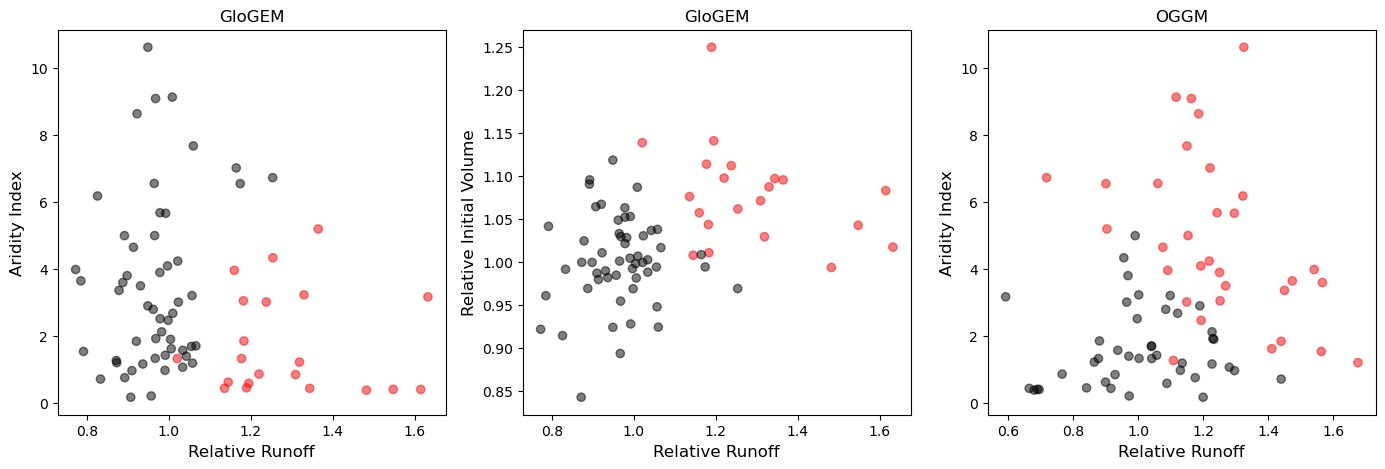

In [96]:
# Instantiate kmeans class
gmodels = ['GloGEM', 'PyGEM', 'OGGM']
k = 2
kmeans = KMeans(init="random", n_clusters=k, n_init=10, max_iter=300, random_state=42)

# Iterate over combinations of parameters
parameter_combinations = list(itertools.combinations(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes'], 2))
# Create a mapping of parameter names to indices
param_indices = {param: idx for idx, param in enumerate(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes'])}

basins_in_clusters = {}
X = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
X_scaled = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
centers = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
cluster_array = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}

for gmodel in gmodels:
    SSP = 'ssp245'
    X[gmodel][SSP] = np.asarray([
            RMQ_GCM_means[gmodel][SSP],
            parameters[gmodel]['Aridity_Index_Avg'],
            relative_init_volume[SSP][gmodel],
            #relative_GlacAreaFrac[gmodel],
        ]).transpose()

    # Standardize the data
    X_scaled[gmodel][SSP] = StandardScaler().fit_transform(X[gmodel][SSP])

    # Perform kmeans
    kmobject = kmeans.fit(X_scaled[gmodel][SSP])
    centers[gmodel][SSP] = kmobject.cluster_centers_
    cluster_labels = kmobject.predict(X_scaled[gmodel][SSP])
    cluster_array[gmodel][SSP] = kmobject.predict(X_scaled[gmodel][SSP])
    

    # Store basins names in each cluster
    basins_in_clusters[(gmodel, SSP)] = {cluster_label: [] for cluster_label in range(k)}
    for row_index, cluster_label in enumerate(cluster_labels):
        basin_name = parameters[gmodel].index[row_index]  # Assuming row indices are the basin names
        basins_in_clusters[(gmodel, SSP)][cluster_label].append(basin_name)

# Create a 1x3 subplot arrangement
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot the 1st subplot
axes[0].scatter(X[gmodels[0]][SSP][:, param_indices[parameter_combinations[0][0]]],
                X[gmodels[0]][SSP][:, param_indices[parameter_combinations[0][1]]],
                c=np.where(cluster_array[gmodels[0]][SSP] == 0, 'red', 'black'), alpha=0.5)
axes[0].set_ylabel('Aridity Index', fontsize = 12)
axes[0].set_xlabel('Relative Runoff', fontsize = 12)
axes[0].set_title('GloGEM')

# Plot the 2nd subplot
axes[1].scatter(X[gmodels[0]][SSP][:, param_indices[parameter_combinations[1][0]]],
                X[gmodels[0]][SSP][:, param_indices[parameter_combinations[1][1]]],
                c=np.where(cluster_array[gmodels[0]][SSP] == 0, 'red', 'black'), alpha=0.5)
axes[1].set_ylabel('Relative Initial Volume', fontsize = 12)
axes[1].set_xlabel('Relative Runoff', fontsize = 12)
axes[1].set_title('GloGEM')

# Plot the 7th subplot
axes[2].scatter(X[gmodels[2]][SSP][:, param_indices[parameter_combinations[0][0]]],
                X[gmodels[2]][SSP][:, param_indices[parameter_combinations[0][1]]],
                c=np.where(cluster_array[gmodels[2]][SSP] == 0, 'red', 'black'), alpha=0.5)
axes[2].set_ylabel('Aridity Index', fontsize = 12)
axes[2].set_xlabel('Relative Runoff', fontsize = 12)
axes[2].set_title('OGGM')

plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/Cluster_Analysis_{SSP}.png", dpi=450, bbox_inches='tight')
plt.show()

# Show the plot
plt.show()

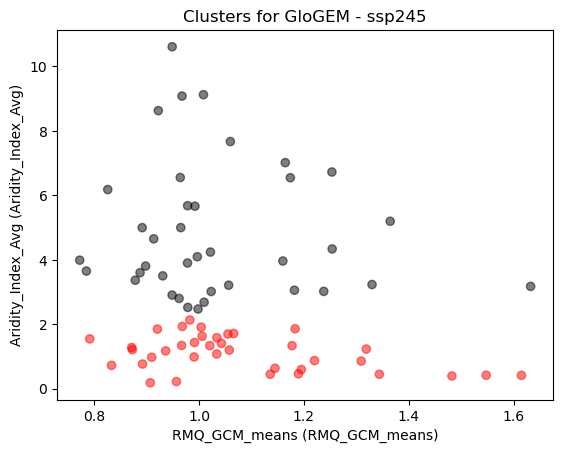

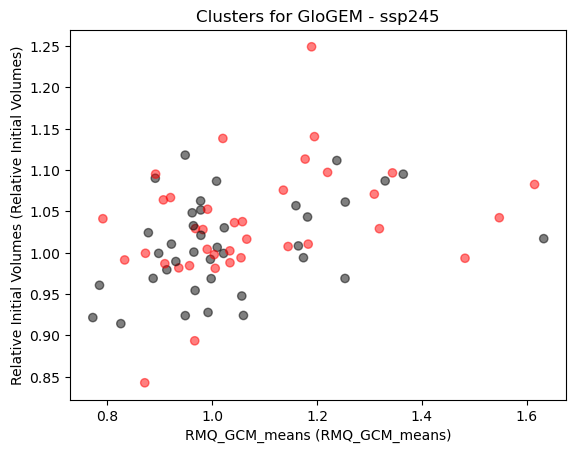

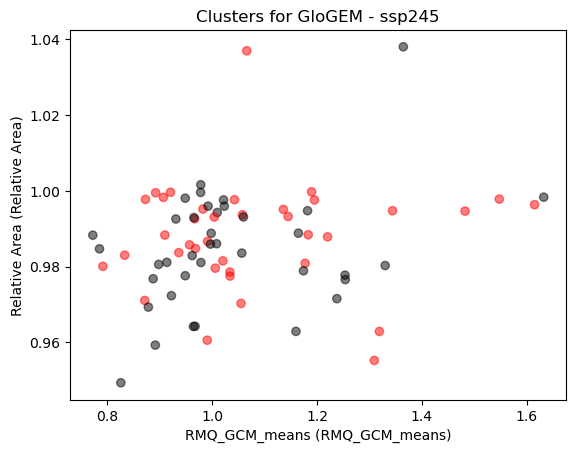

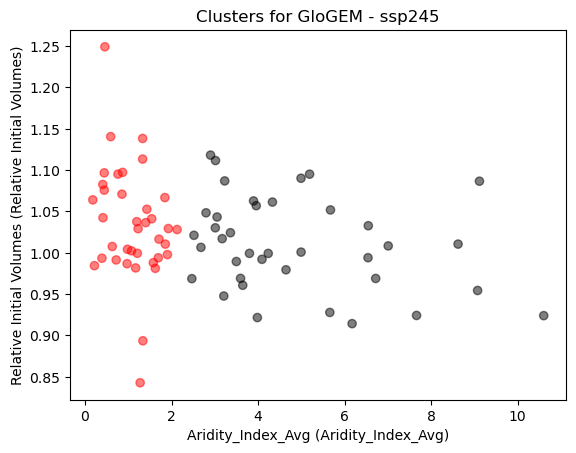

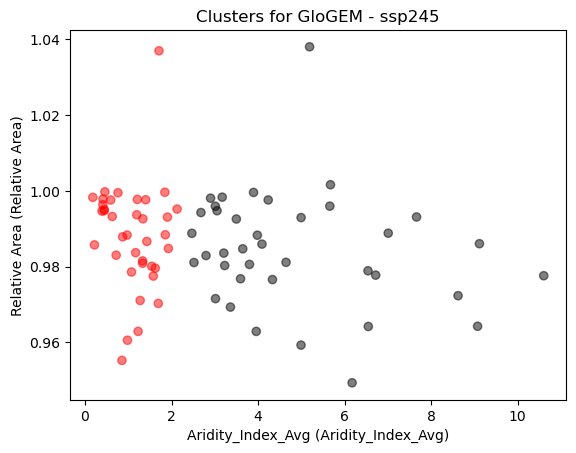

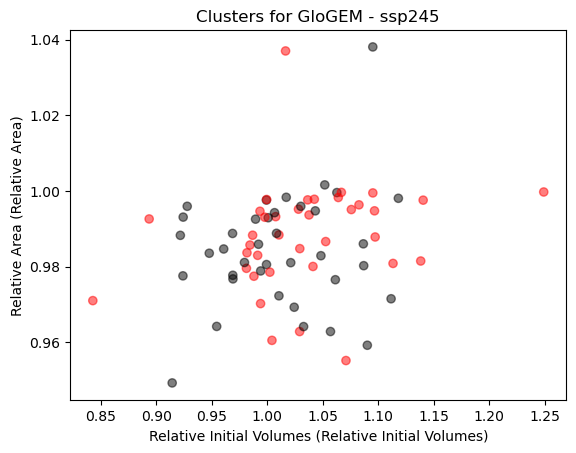

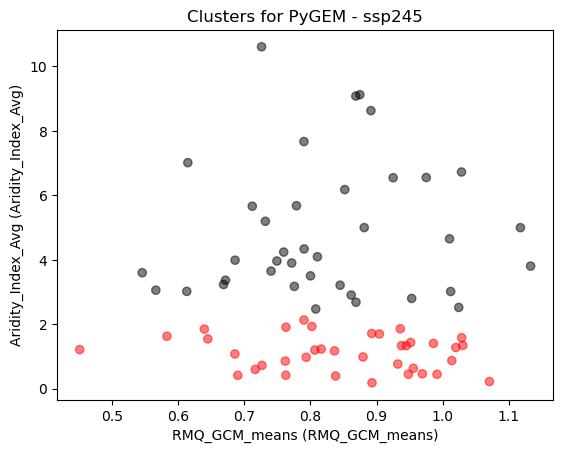

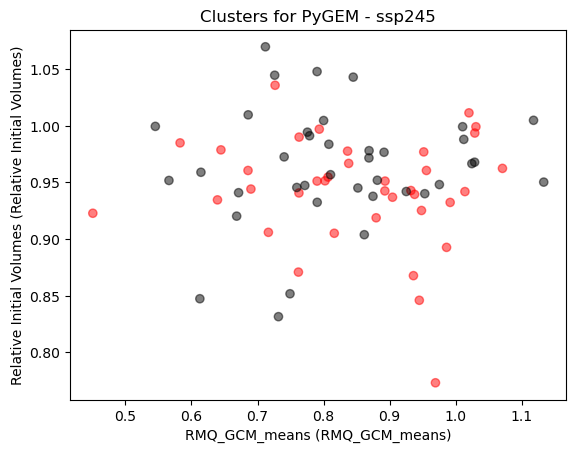

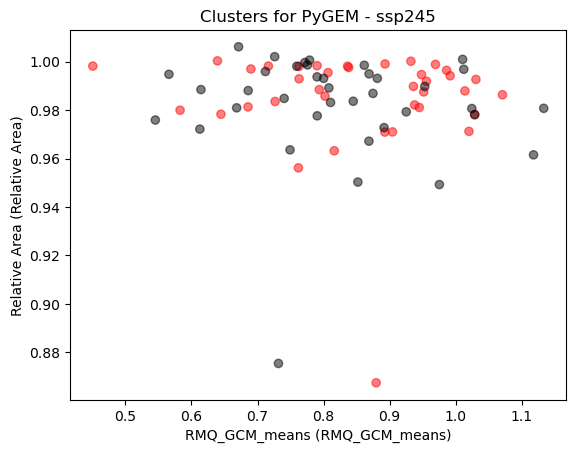

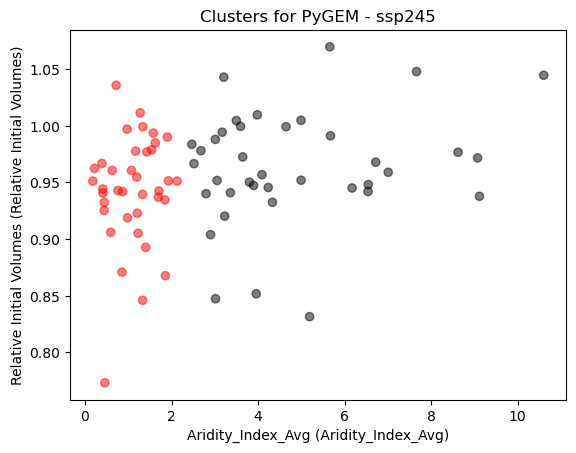

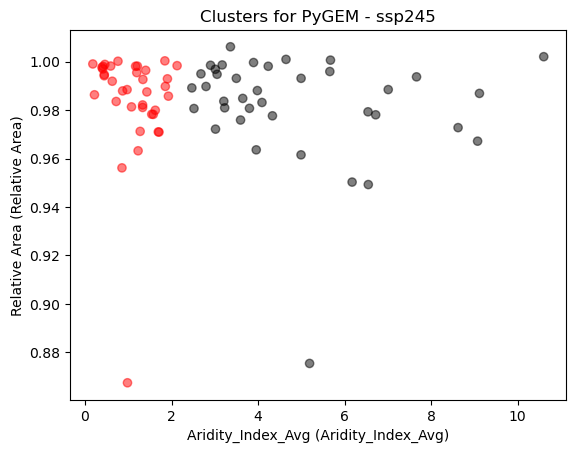

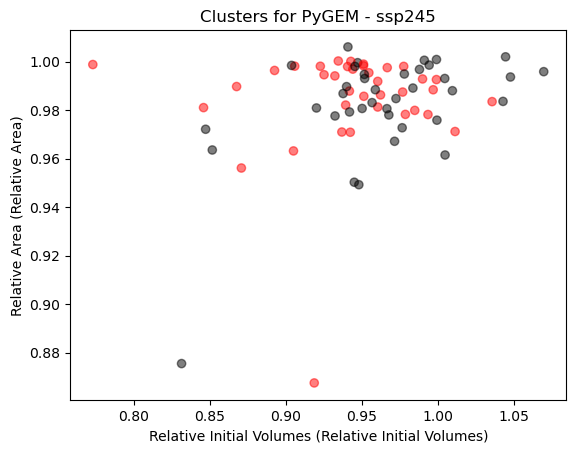

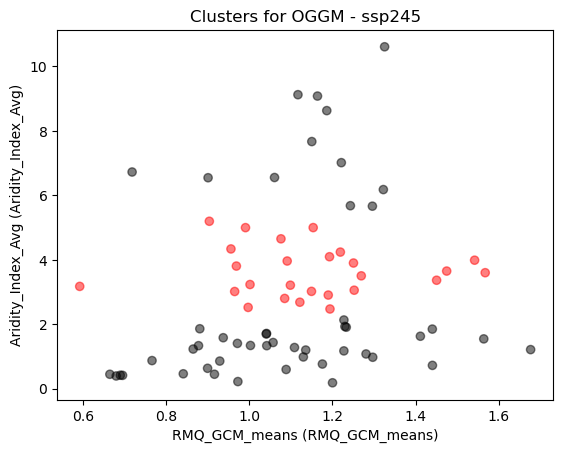

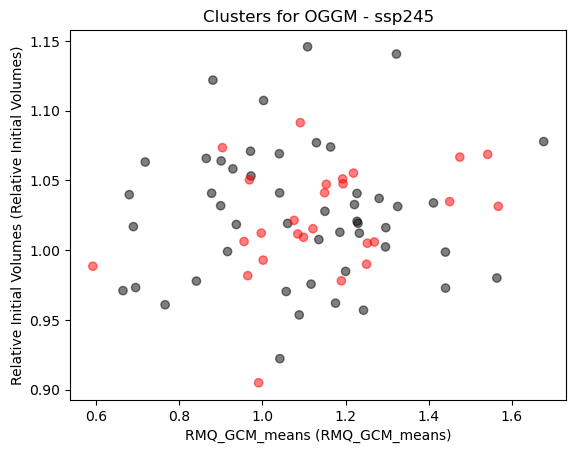

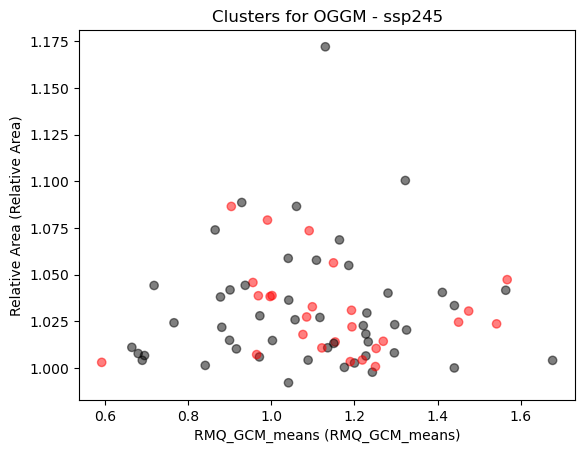

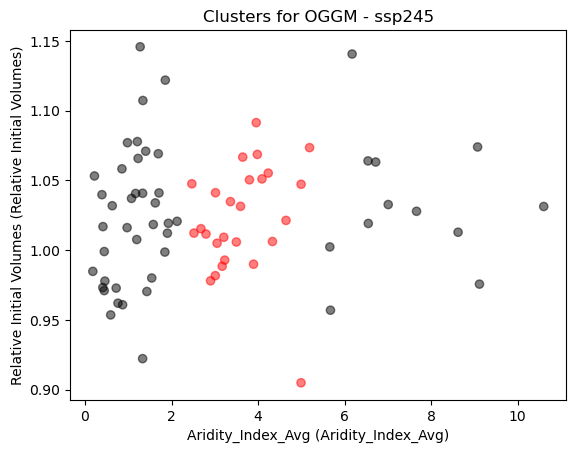

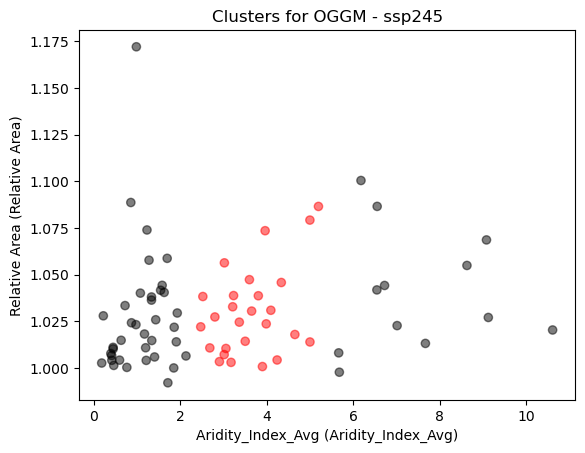

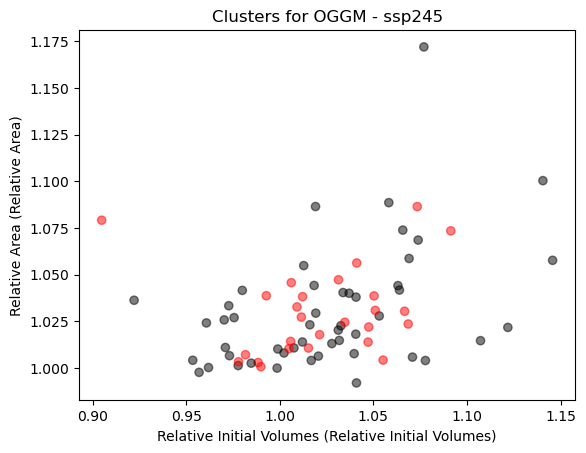

In [104]:
# Instantiate kmeans class
gmodels = ['GloGEM', 'PyGEM', 'OGGM']
k = 3
kmeans = KMeans(init="random", n_clusters=k, n_init=10, max_iter=300, random_state=42)

# # Iterate over combinations of parameters
# parameter_combinations = list(itertools.combinations(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes'], 2))
# # Create a mapping of parameter names to indices
# param_indices = {param: idx for idx, param in enumerate(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes'])}

# Iterate over combinations of parameters
parameter_combinations = list(itertools.combinations(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes', 'Relative Area'], 2))
# Create a mapping of parameter names to indices
param_indices = {param: idx for idx, param in enumerate(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes', 'Relative Area'])}

basins_in_clusters = {}
X = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
X_scaled = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
centers = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
cluster_array = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}

for gmodel in gmodels:
    SSP = 'ssp245'
    X[gmodel][SSP] = np.asarray([
            RMQ_GCM_means[gmodel][SSP],
            parameters[gmodel]['Aridity_Index_Avg'],
            relative_init_volume[SSP][gmodel],
            #parameters[gmodel]['Average Precipitation Trend']
            relative_GlacAreaFrac[gmodel],
        ]).transpose()

    # Standardize the data
    X_scaled[gmodel][SSP] = StandardScaler().fit_transform(X[gmodel][SSP])

    # Perform kmeans
    # kmobject = kmeans.fit(X_scaled[gmodel][SSP])
    # centers[gmodel][SSP] = kmobject.cluster_centers_
    # cluster_labels = kmobject.predict(X_scaled[gmodel][SSP])
    # cluster_array[gmodel][SSP] = kmobject.predict(X_scaled[gmodel][SSP])

    # Perform kmeans
    kmobject = kmeans.fit(X[gmodel][SSP])
    centers[gmodel][SSP] = kmobject.cluster_centers_
    cluster_labels = kmobject.predict(X[gmodel][SSP])
    cluster_array[gmodel][SSP] = kmobject.predict(X[gmodel][SSP])
    

    # Store basins names in each cluster
    basins_in_clusters[(gmodel, SSP)] = {cluster_label: [] for cluster_label in range(k)}
    for row_index, cluster_label in enumerate(cluster_labels):
        basin_name = parameters[gmodel].index[row_index]  # Assuming row indices are the basin names
        basins_in_clusters[(gmodel, SSP)][cluster_label].append(basin_name)
    for param1, param2 in parameter_combinations:
        idx1, idx2 = param_indices[param1], param_indices[param2]
        plt.scatter(X[gmodel][SSP][:, idx1], X[gmodel][SSP][:, idx2], c=np.where(cluster_array[gmodel][SSP] == 0, 'red', 'black'), alpha=0.5)
        #plt.scatter(centers[gmodel][SSP][:, idx1], centers[gmodel][SSP][:, idx2], marker='X', s=200, c='white', edgecolors='black')
        plt.xlabel(f"{param1} ({param1})")
        plt.ylabel(f"{param2} ({param2})")
        plt.title(f'Clusters for {gmodel} - {SSP}')
        plt.show()

In [19]:
parameter_combinations

[('RMQ_GCM_means', 'Aridity_Index_Avg'),
 ('RMQ_GCM_means', 'Relative Initial Volumes'),
 ('Aridity_Index_Avg', 'Relative Initial Volumes')]

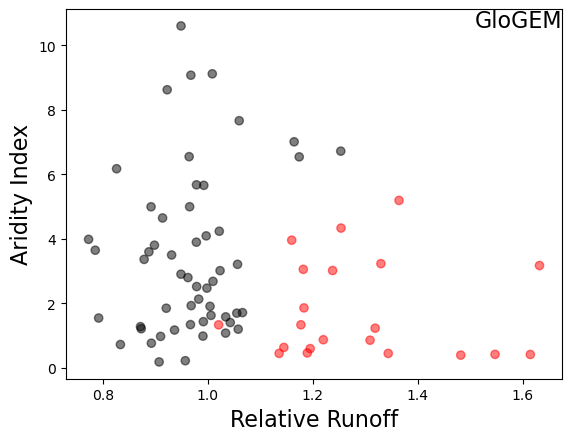

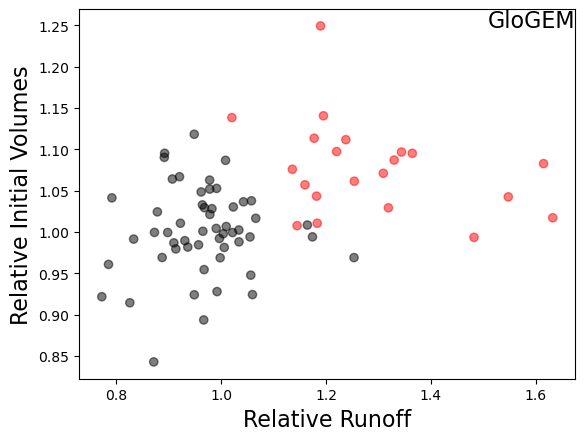

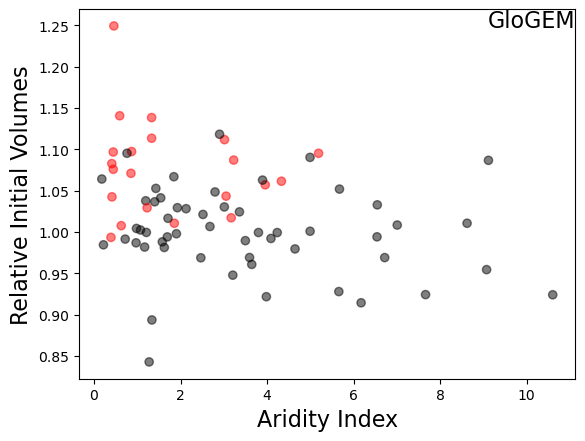

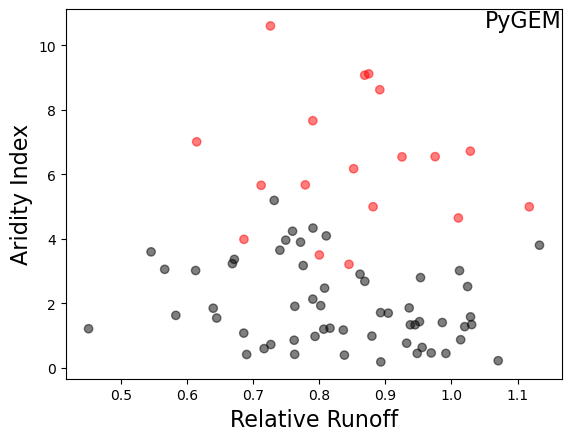

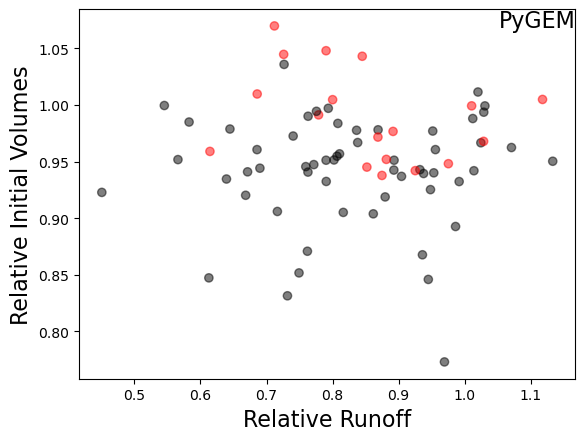

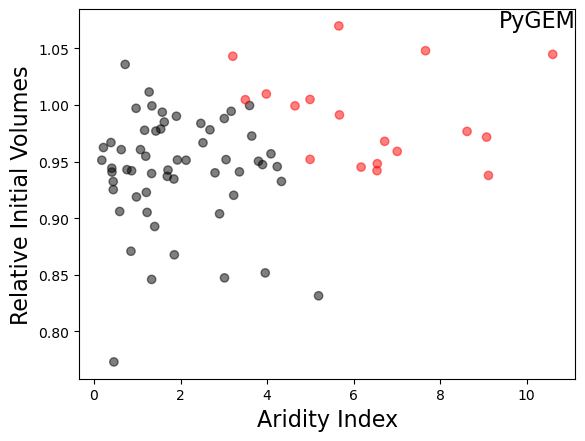

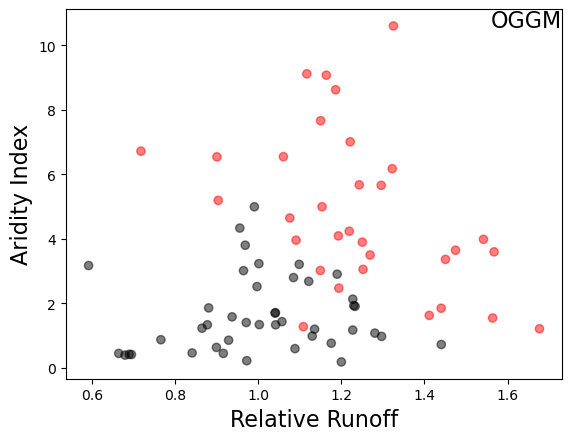

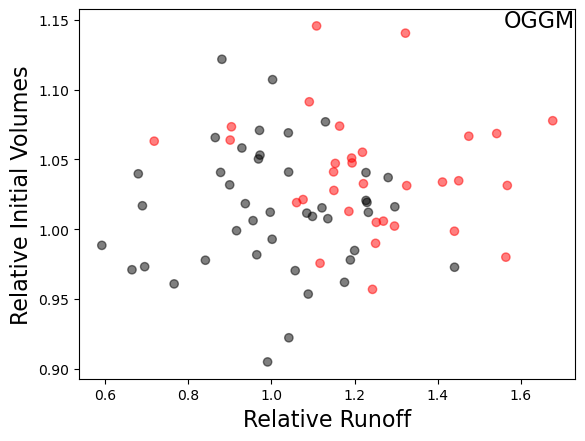

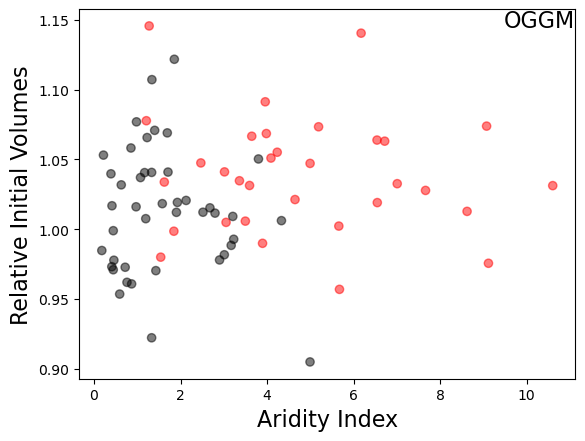

In [99]:
# Instantiate kmeans class
gmodels = ['GloGEM', 'PyGEM', 'OGGM']
k = 2
kmeans = KMeans(init="random", n_clusters=k, n_init=10, max_iter=300, random_state=42)

# Iterate over combinations of parameters
parameter_combinations = list(itertools.combinations(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes'], 2))
# Create a mapping of parameter names to indices
param_indices = {param: idx for idx, param in enumerate(['RMQ_GCM_means', 'Aridity_Index_Avg', 'Relative Initial Volumes'])}

basins_in_clusters = {}
X = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
X_scaled = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
centers = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}
cluster_array = {gmodel: {SSP: None for SSP in scenarios} for gmodel in gmodels}

for gmodel in gmodels:
    SSP = 'ssp245'
    X[gmodel][SSP] = np.asarray([
            RMQ_GCM_means[gmodel][SSP],
            parameters[gmodel]['Aridity_Index_Avg'],
            relative_init_volume[SSP][gmodel],
            #relative_GlacAreaFrac[gmodel],
        ]).transpose()

    # Standardize the data
    X_scaled[gmodel][SSP] = StandardScaler().fit_transform(X[gmodel][SSP])

    # Perform kmeans
    kmobject = kmeans.fit(X_scaled[gmodel][SSP])
    centers[gmodel][SSP] = kmobject.cluster_centers_
    cluster_labels = kmobject.predict(X_scaled[gmodel][SSP])
    cluster_array[gmodel][SSP] = kmobject.predict(X_scaled[gmodel][SSP])
    

    # Store basins names in each cluster
    basins_in_clusters[(gmodel, SSP)] = {cluster_label: [] for cluster_label in range(k)}
    for row_index, cluster_label in enumerate(cluster_labels):
        basin_name = parameters[gmodel].index[row_index]  # Assuming row indices are the basin names
        basins_in_clusters[(gmodel, SSP)][cluster_label].append(basin_name)
    for param1, param2 in parameter_combinations:
        idx1, idx2 = param_indices[param1], param_indices[param2]
        
        # Map parameter names to desired labels
        label_dict = {'Aridity_Index_Avg': 'Aridity Index', 'RMQ_GCM_means': 'Relative Runoff', 'Relative Initial Volumes': 'Relative Initial Volumes'}
        label1 = label_dict[param1]
        label2 = label_dict[param2]
        
        plt.scatter(X[gmodel][SSP][:, idx1], X[gmodel][SSP][:, idx2], c=np.where(cluster_array[gmodel][SSP] == 0, 'red', 'black'), alpha=0.5)
        # Set plot limits based on the maximum and minimum values
        #plt.xlim(np.min(X[gmodel][SSP][:, idx1]) * 0.8, np.max(X[gmodel][SSP][:, idx1]) * 1.1)
        #plt.ylim(np.min(X[gmodel][SSP][:, idx2]) - (np.max(X[gmodel][SSP][:, idx2]*0.1)), np.max(X[gmodel][SSP][:, idx2]) +  np.max(X[gmodel][SSP][:, idx2])*0.04)
        
        # Dynamically position the text based on the maximum values
        #plt.text(np.max(X[gmodel][SSP][:, idx1]), np.max(X[gmodel][SSP][:, idx2]), gmodel)
        plt.text(plt.xlim()[1], plt.ylim()[1], gmodel, ha='right', va='top', fontsize = 16)
        
        #plt.scatter(centers[gmodel][SSP][:, idx1], centers[gmodel][SSP][:, idx2], marker='X', s=200, c='white', edgecolors='black')
        plt.xlabel(f"{label1}", fontsize = 16)
        plt.ylabel(f"{label2}", fontsize = 16)
        #plt.title(f'{gmodel} - {SSP}')
        plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/AGU Figures/f'{gmodel}_{label1}_{label2}'.png", dpi=300, bbox_inches='tight')
        plt.show()
        
